<a href="https://colab.research.google.com/github/ved-ingole/MNIST-Handwritten-Digit-Classification/blob/main/MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("oddrationale/mnist-in-csv")

print("Path to dataset files:", path)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mlt

print(os.listdir(path))
data = pd.read_csv(os.path.join(path, "mnist_train.csv"))

Using Colab cache for faster access to the 'mnist-in-csv' dataset.
Path to dataset files: /kaggle/input/mnist-in-csv
['mnist_test.csv', 'mnist_train.csv']


In [ ]:
data.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
data = np.array(data)
m, n = data.shape
np.random.shuffle(data) #remove noise

In [ ]:
print(m,n)

60000 785


In [ ]:
train_data = data[0:int(0.8*m), :] #Training
val_data = data[int(0.8*m):m, :]

X_train = train_data[:, 1:].T #Validation
X_train = X_train / 255.0
Y_train = train_data[:, 0]

X_val = val_data[:, 1:].T #Testing
X_val = X_val / 255.0
Y_val = val_data[:, 0]


In [ ]:
print(X_val.shape)
print(Y_val.shape)
print(X_train.shape)
print(Y_train.shape)

(784, 12000)
(12000,)
(784, 48000)
(48000,)


In [ ]:
#Created model
def initialize_parameters():
  W1 = np.random.rand(10, 784) - 0.5
  B1 = np.random.rand(10, 1) - 0.5
  W2 = np.random.rand(10, 10) - 0.5
  B2 = np.random.rand(10, 1) - 0.5

  return W1, B1, W2, B2

def ReLU(X):
  return np.maximum(X, 0)

def softmax_calculator(Z):
  return np.exp(Z) / sum(np.exp(Z))

def forward_propagation(W1, B1, W2, B2, X):
  Z1 = W1.dot(X) + B1
  A1 = ReLU(Z1)
  Z2 = W2.dot(A1) + B2
  A2 = softmax_calculator(Z2)
  return Z1, A1, Z2, A2

def one_hot_converter(Y):
  one_hot_Y = np.zeros((Y.size, Y.max() + 1))
  one_hot_Y[np.arange(Y.size), Y] = 1
  return one_hot_Y.T

def backward_propagation(W1, B1, W2, B2, Z1, A1, Z2, A2, X, Y):
  one_hot_Y = one_hot_converter(Y)
  dZ2 = A2 - one_hot_Y
  dW2 = 1 / m * dZ2.dot(A1.T)
  dB2 = 1 / m * np.sum(dZ2)
  dZ1 = W2.T.dot(dZ2) * (Z1 > 0)
  dW1 = 1 / m * dZ1.dot(X.T)
  dB1 = 1 / m * np.sum(dZ1)
  return dW1, dB1, dW2, dB2

def update_parameters(W1, B1, W2, B2, dW1, dB1, dW2, dB2, learning_rate):
  W1 = W1 - learning_rate * dW1
  B1 = B1 - learning_rate * dB1
  W2 = W2 - learning_rate * dW2
  B2 = B2 - learning_rate * dB2
  return W1, B1, W2, B2

def get_prediction(A2):
  return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
  return np.sum(predictions == Y) / Y.size

def gradient_decent(X, Y, alpha, iterations):
  W1, B1, W2, B2 = initialize_parameters()

  for i in range(iterations):
    Z1, A1, Z2, A2 = forward_propagation(W1, B1, W2, B2, X)
    dW1, dB1, dW2, dB2 = backward_propagation(W1, B1, W2, B2, Z1, A1, Z2, A2, X, Y)
    W1, B1, W2, B2 = update_parameters(W1, B1, W2, B2, dW1, dB1, dW2, dB2, alpha)

    if (i%20)==0:
      print("Iteration number: ", i)
      print("Accuracy = ", get_accuracy(get_prediction(A2), Y))
  return W1, B1, W2, B2


In [ ]:
W1, B1, W2, B2 = gradient_decent(X_train, Y_train, 0.1, 5000)

Iteration number:  0
Accuracy =  0.07972916666666667
Iteration number:  20
Accuracy =  0.2308125
Iteration number:  40
Accuracy =  0.3531458333333333
Iteration number:  60
Accuracy =  0.45366666666666666
Iteration number:  80
Accuracy =  0.5297291666666667
Iteration number:  100
Accuracy =  0.5844583333333333
Iteration number:  120
Accuracy =  0.6258958333333333
Iteration number:  140
Accuracy =  0.6577083333333333
Iteration number:  160
Accuracy =  0.6824375
Iteration number:  180
Accuracy =  0.7030833333333333
Iteration number:  200
Accuracy =  0.7185208333333334
Iteration number:  220
Accuracy =  0.7321458333333334
Iteration number:  240
Accuracy =  0.7428125
Iteration number:  260
Accuracy =  0.7515833333333334
Iteration number:  280
Accuracy =  0.7603958333333334
Iteration number:  300
Accuracy =  0.7681041666666667
Iteration number:  320
Accuracy =  0.7750208333333334
Iteration number:  340
Accuracy =  0.78125
Iteration number:  360
Accuracy =  0.7876458333333334
Iteration number

Predicted lable:  [3]
Actual Value:  3


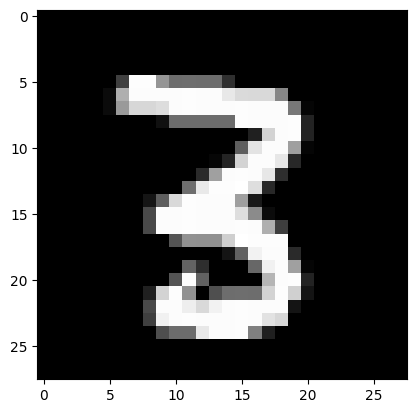

In [ ]:
val_index = 700
Z1val, A1val, Z2val, A2val = forward_propagation(W1, B1, W2, B2, X_val[:, val_index, None])
print("Predicted lable: ", get_prediction(A2val))
print("Actual Value: ", Y_val[val_index])

image_array = X_val[:,val_index].reshape(28,28)
plt.imshow(image_array, cmap='gray')
plt.show()

In [ ]:
Z1val, A1val, Z2val, A2val = forward_propagation(W1, B2, W2, B2, X_val)
val_acc = get_accuracy(get_prediction(A2val), Y_val)
print("Validation accuracy = ", val_acc)

Validation accuracy =  0.8854166666666666
